In [9]:
from typing import TypedDict, Annotated
import random
from IPython.display import Image, display
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_openai import ChatOpenAI
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, AnyMessage, RemoveMessage
from langgraph.checkpoint.memory import MemorySaver
from operator import add
from pprint import pprint

model = ChatOpenAI(model_name="gpt-5-nano")
checkpointer = MemorySaver()

In [4]:
from os import name


messages = [
  AIMessage(f"So you said you were researching agentic systems?", name="AI"),
]
messages.append(HumanMessage(f"Yes, I am. But I'm not sure how to master it.", name="User"))

for m in messages:
  m.pretty_print()


================================== Ai Message ==================================
Name: AI

So you said you were researching agentic systems?
================================ Human Message =================================
Name: User

Yes, I am. But I'm not sure how to master it.


In [5]:
model.invoke(messages)

AIMessage(content='Nice. “Agentic systems” usually means autonomous software that can perceive, decide, and act to pursue goals, sometimes with memory, planning, and tool use. Mastery combines theory, practical engineering, and safety/governance. Here’s a practical, beginner-to-advanced plan you can follow, plus options to tailor to your goals.\n\nCore ideas to understand\n- Agent vs environment: an agent has beliefs/goals/intentions and chooses actions to affect the environment.\n- Autonomy levels: reactive agents (no planning) vs deliberative agents (planning + reasoning) vs hybrid (think-then-act loops).\n- Key architectures: Belief-Desire-Intention (BDI), planning + execution, and modern “think-before-act” patterns like tool-using agents (ReAct, etc.).\n- Safety and alignment: failure modes (hallucinations, goal leakage), need for guardrails, monitoring, kill-switches, and auditability.\n\nA practical learning roadmap (with milestones)\n1) Foundations (4–8 weeks)\n- Math and theory

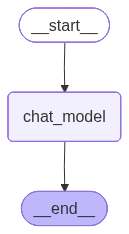

In [7]:
def chat_model_node(state: MessagesState) -> MessagesState:
    response = model.invoke(state["messages"])
    return {"messages": [response]}

builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [8]:
output = graph.invoke({"messages": messages})

for m in output["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Name: AI

So you said you were researching agentic systems?
================================ Human Message =================================
Name: User

Yes, I am. But I'm not sure how to master it.
================================== Ai Message ==================================

Nice goal. “Mastering agentic systems” can mean different things (theory, implementation, safety, governance, or all of the above). I’ll give you a practical, safe path you can adapt, plus some starter ideas and resources. If you tell me your domain (software agents, robotics, finance, games, etc.), I can tailor it more.

What “mastery” typically involves
- Theory: how agents think, decide, plan, learn, and coordinate (BDI architecture, planning, RL, multi-agent systems).
- Practice: building and testing agents, integrating them with environments, debugging, performance.
- Safety and ethics: ensuring agents act safely, predictably

In [14]:
def filter_messages(state: MessagesState) -> MessagesState:
    delete_messages = [RemoveMessage(id=msg.id) for msg in state["messages"][:-2]]
    return {"messages": delete_messages}

def chat_model_node(state: MessagesState) -> MessagesState:
    return {"messages": [model.invoke(state["messages"])]}

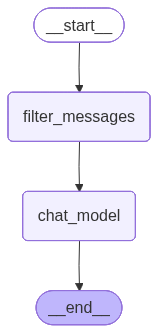

In [15]:
builder = StateGraph(MessagesState)
builder.add_node("filter_messages", filter_messages)
builder.add_node("chat_model", chat_model_node)

builder.add_edge(START, "filter_messages")
builder.add_edge("filter_messages", "chat_model")
builder.add_edge("chat_model", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
messages = [AIMessage(content="Hello! How can I help you today?")]
messages.append(HumanMessage(content="What is the capital of France?"))
messages.append(AIMessage(content="The capital of France is Paris."))
messages.append(HumanMessage(content="Thank you!"))

output = graph.invoke({"messages": messages})
for message in output["messages"]:
    message.pretty_print()

================================== Ai Message ==================================

The capital of France is Paris.
================================ Human Message =================================

Thank you!
================================== Ai Message ==================================

You're welcome! If you have any other questions—about Paris, other capitals, travel tips, or anything else—just let me know.
